### Cell 1: Import thư viện và các module đã tách

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Import từ các file của bạn
from config import *
from data_utils import *
from model_utils import *

### Cell 2: Đọc và Xử lý dữ liệu (ETL)

In [ ]:
# Đọc data thô
df_fake = pd.read_csv(RAW_FAKE_PATH); df_fake['label'] = 1
df_true = pd.read_csv(RAW_TRUE_PATH); df_true['label'] = 0

explore_raw_data(df_fake, "TẬP TIN GIẢ (FAKE.CSV)")
explore_raw_data(df_true, "TẬP TIN THẬT (TRUE.CSV)")

df_fake['date_parsed'] = pd.to_datetime(df_fake['date'], errors='coerce')
df_true['date_parsed'] = pd.to_datetime(df_true['date'], errors='coerce')

df_fake = df_fake.dropna(subset=['date_parsed']).sort_values('date_parsed').reset_index(drop=True)
df_true = df_true.dropna(subset=['date_parsed']).sort_values('date_parsed').reset_index(drop=True)

df_fake['is_test'] = False
df_fake.loc[int(len(df_fake) * 0.8):, 'is_test'] = True

df_true['is_test'] = False
df_true.loc[int(len(df_true) * 0.8):, 'is_test'] = True


df = pd.concat([df_fake, df_true], axis=0).reset_index(drop=True)
df = df.drop_duplicates(subset=['text']).dropna(subset=['text']).reset_index(drop=True)

df['text_clean_raw'] = df['text'].apply(deep_clean_text)
df['title_text_clean_raw'] = (df['title'] + " " + df['text']).apply(deep_clean_text)
df['title_only_clean_raw'] = df['title'].apply(deep_clean_text)
df['text_only_clean'] = df['text_clean_raw'].apply(lemmatize_and_remove_stopwords)
df['title_text_clean'] = df['title_text_clean_raw'].apply(lemmatize_and_remove_stopwords)
df['title_only_clean'] = df['title_only_clean_raw'].apply(lemmatize_and_remove_stopwords)

# Xóa trùng lặp sâu
df = df.drop_duplicates(subset=['text_only_clean']).reset_index(drop=True) # type: ignore
df = df[df['text_only_clean'].str.strip() != ""].reset_index(drop=True)

train_idx = df[df['is_test'] == False].index
test_idx = df[df['is_test'] == True].index
y_train = df.loc[train_idx, 'label']
y_test = df.loc[test_idx, 'label']

df.drop(columns=['subject', 'date', 'date_parsed', 'is_test'], inplace=True, errors='ignore')

explore_processed_data(df, train_idx, test_idx)

test_idx = remove_data_leakage_from_test(df, train_idx, test_idx, clean_col='text_only_clean')
y_test = df.loc[test_idx, 'label']

📊 THỐNG KÊ DỮ LIỆU THÔ: TẬP TIN GIẢ (FAKE.CSV)
1. Kích thước tập dữ liệu:
   - Số dòng (Bài báo): 23,481
   - Số cột (Đặc trưng): 5

2. Số lượng giá trị thiếu (Missing Values):
   -> Tuyệt vời! Không có giá trị nào bị thiếu.

3. Số lượng dòng trùng lặp (Duplicates):
   -> Phát hiện 3 dòng bị trùng lặp hoàn toàn trên toàn bộ cột.

4. Danh sách các cột và kiểu dữ liệu:
   - title           : str
   - text            : str
   - subject         : str
   - date            : str
   - label           : int64


📊 THỐNG KÊ DỮ LIỆU THÔ: TẬP TIN THẬT (TRUE.CSV)
1. Kích thước tập dữ liệu:
   - Số dòng (Bài báo): 21,417
   - Số cột (Đặc trưng): 5

2. Số lượng giá trị thiếu (Missing Values):
   -> Tuyệt vời! Không có giá trị nào bị thiếu.

3. Số lượng dòng trùng lặp (Duplicates):
   -> Phát hiện 206 dòng bị trùng lặp hoàn toàn trên toàn bộ cột.

4. Danh sách các cột và kiểu dữ liệu:
   - title           : str
   - text            : str
   - subject         : str
   - date            : str
   - label

### Cell 3: Phân tích EDA

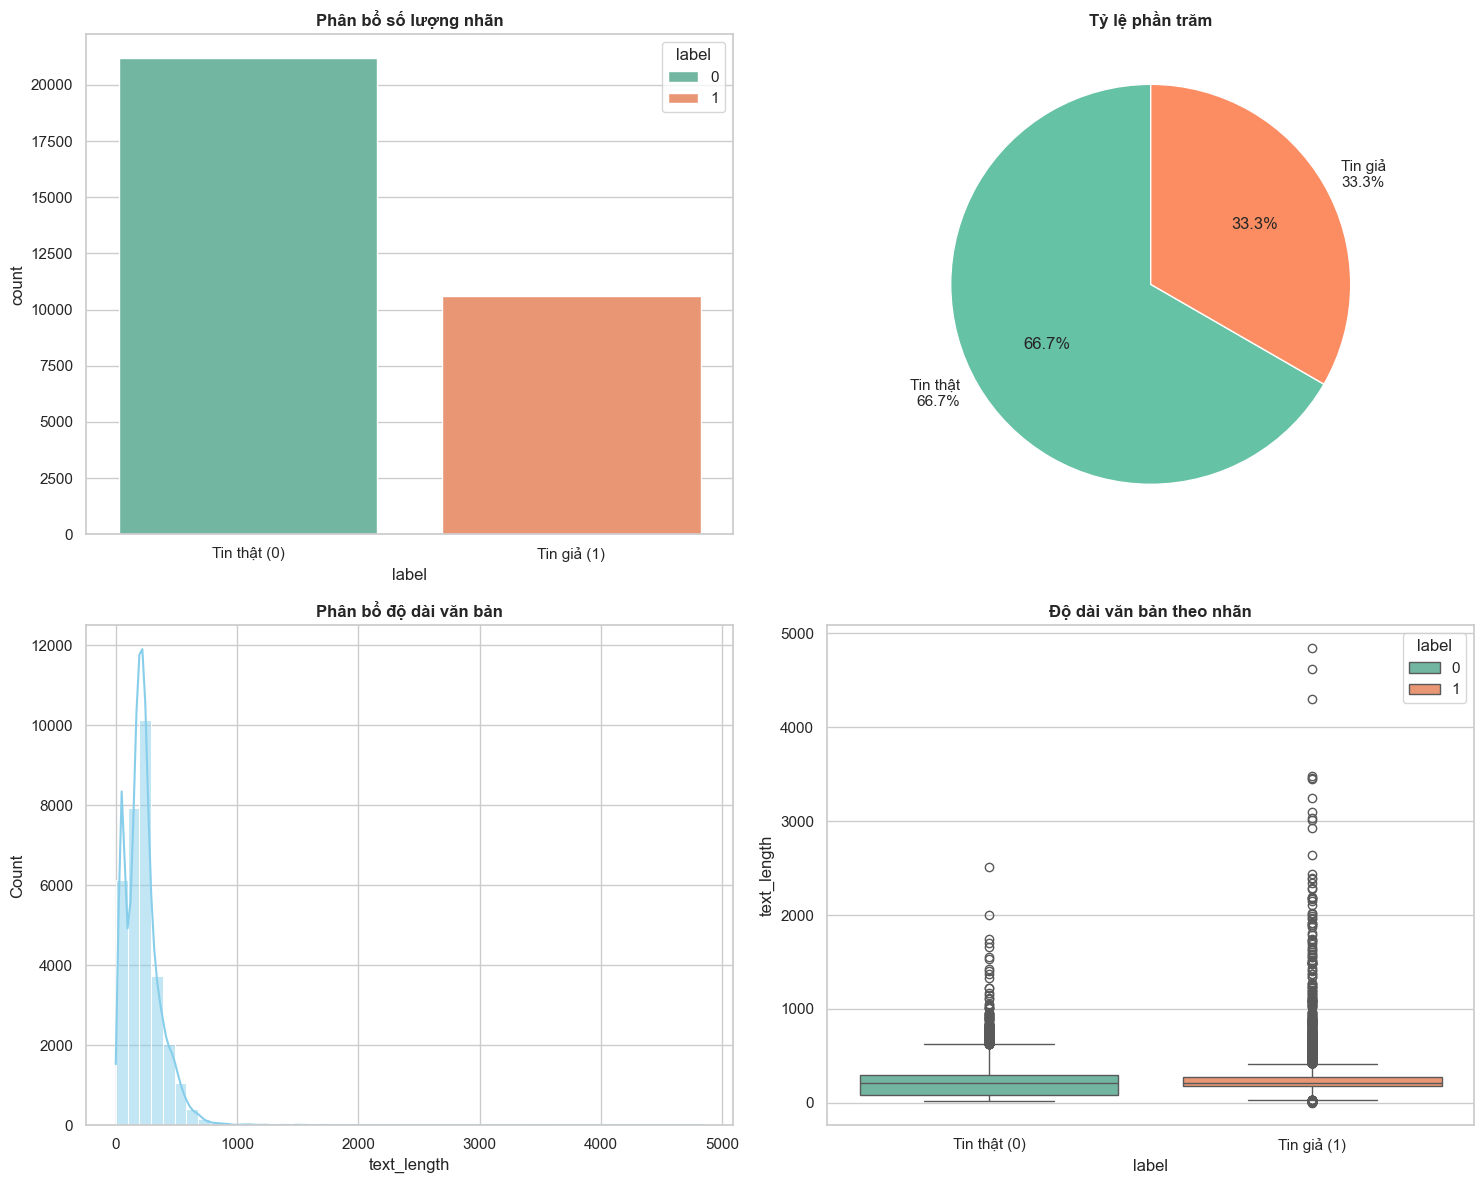

In [3]:
plot_eda(df)

### Cell 4: Xây dựng Feature Pipeline

In [4]:
X_train_text, X_test_text, tfidf_text = build_feature_pipeline(df, train_idx, test_idx, 'text_only_clean', 'text_clean_raw')
X_train_title, X_test_title, tfidf_title = build_feature_pipeline(df, train_idx, test_idx, 'title_text_clean', 'title_text_clean_raw')
X_train_title_only, X_test_title_only, tfidf_title_only = build_feature_pipeline(df, train_idx, test_idx, 'title_only_clean', 'title_only_clean_raw')

### Cell 5: Huấn luyện Mô hình

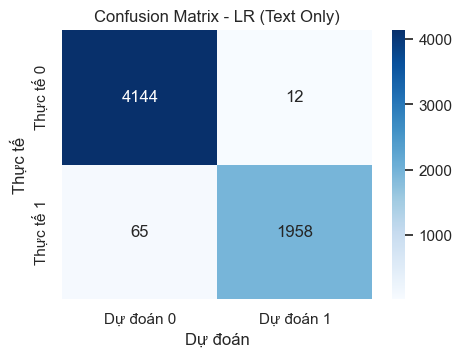

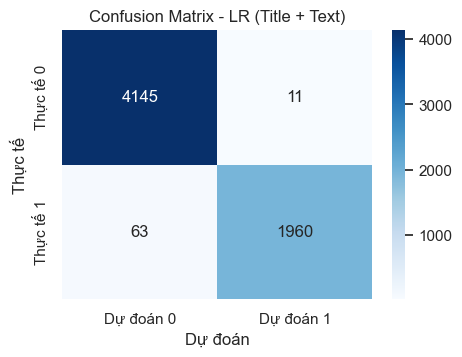

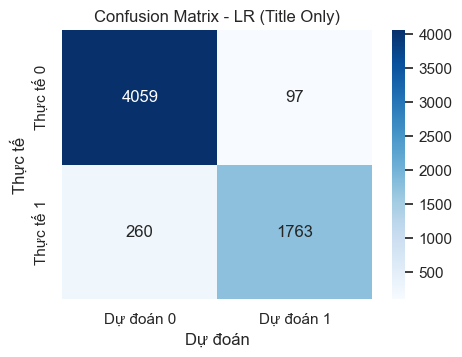

                             SO SÁNH MÔ HÌNH: LOGISTIC REGRESSION                              
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.985                0.985                0.940
Tin thật Recall                          0.997                0.997                0.977
Tin thật F1-score                        0.991                0.991                0.958
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.994                0.994                0.948
Tin giả Recall                           0.969                0.968                0.871
Tin giả F1-score                         0.981                0.981                0.908
-----------------------------------------------------------------------------------------

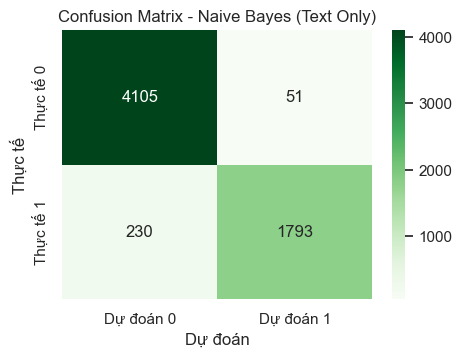

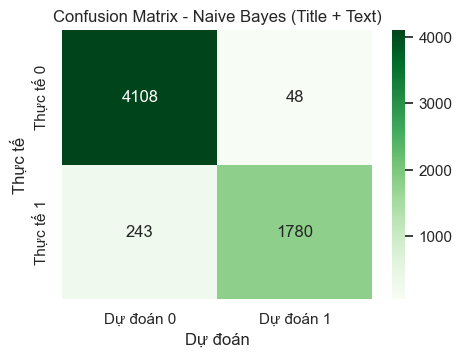

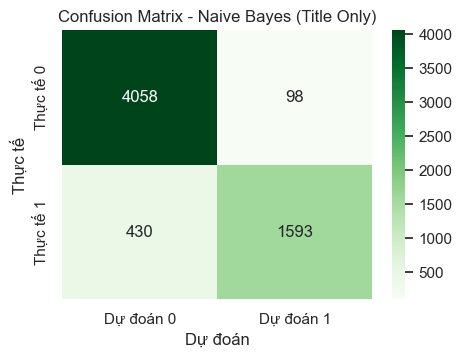

                                 SO SÁNH MÔ HÌNH: NAIVE BAYES                                  
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.944                0.947                0.904
Tin thật Recall                          0.988                0.988                0.976
Tin thật F1-score                        0.966                0.967                0.939
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.974                0.972                0.942
Tin giả Recall                           0.880                0.886                0.787
Tin giả F1-score                         0.924                0.927                0.858
-----------------------------------------------------------------------------------------

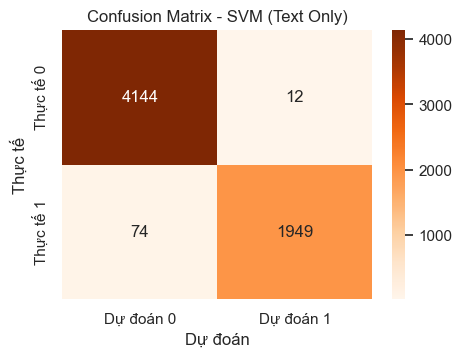

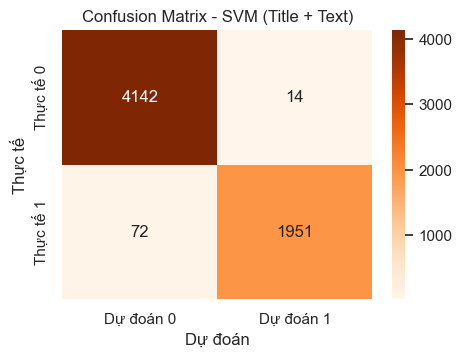

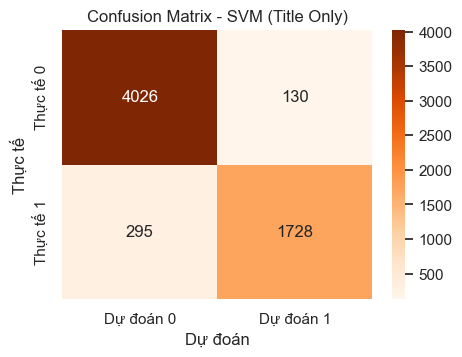

                                     SO SÁNH MÔ HÌNH: SVM                                      
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.983                0.982                0.932
Tin thật Recall                          0.997                0.997                0.969
Tin thật F1-score                        0.990                0.990                0.950
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.993                0.994                0.930
Tin giả Recall                           0.964                0.963                0.854
Tin giả F1-score                         0.978                0.978                0.890
-----------------------------------------------------------------------------------------

In [5]:
all_results = []

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
acc_lr_text, rep_lr_text = train_and_evaluate_model(lr_model, "LR (Text Only)", X_train_text, y_train, X_test_text, y_test, "Blues")
acc_lr_title, rep_lr_title = train_and_evaluate_model(lr_model, "LR (Title + Text)", X_train_title, y_train, X_test_title, y_test, "Blues")
acc_lr_title_only, rep_lr_title_only = train_and_evaluate_model(lr_model, "LR (Title Only)", X_train_title_only, y_train, X_test_title_only, y_test, "Blues")

display_comparison_report("LOGISTIC REGRESSION", acc_lr_title, rep_lr_title, acc_lr_text, rep_lr_text, acc_lr_title_only, rep_lr_title_only)

all_results.extend([
    ("Logistic Regression", "Text Only", acc_lr_text, rep_lr_text),
    ("Logistic Regression", "Title + Text", acc_lr_title, rep_lr_title),
    ("Logistic Regression", "Title Only", acc_lr_title_only, rep_lr_title_only)
])

# 2. Naive Bayes
print("--- HUẤN LUYỆN NAIVE BAYES ---")
nb_model = MultinomialNB()

acc_nb_text, rep_nb_text = train_and_evaluate_model(nb_model, "Naive Bayes (Text Only)", X_train_text, y_train, X_test_text, y_test, "Greens")
acc_nb_title, rep_nb_title = train_and_evaluate_model(nb_model, "Naive Bayes (Title + Text)", X_train_title, y_train, X_test_title, y_test, "Greens")
acc_nb_title_only, rep_nb_title_only = train_and_evaluate_model(nb_model, "Naive Bayes (Title Only)", X_train_title_only, y_train, X_test_title_only, y_test, "Greens")

display_comparison_report("NAIVE BAYES", acc_nb_title, rep_nb_title, acc_nb_text, rep_nb_text, acc_nb_title_only, rep_nb_title_only)

all_results.extend([
    ("Naive Bayes", "Text Only", acc_nb_text, rep_nb_text),
    ("Naive Bayes", "Title + Text", acc_nb_title, rep_nb_title),
    ("Naive Bayes", "Title Only", acc_nb_title_only, rep_nb_title_only)
])

# 3. SVM
print("--- HUẤN LUYỆN SVM ---")
svm_model = LinearSVC(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced')

acc_svm_text, rep_svm_text = train_and_evaluate_model(svm_model, "SVM (Text Only)", X_train_text, y_train, X_test_text, y_test, "Oranges")
acc_svm_title, rep_svm_title = train_and_evaluate_model(svm_model, "SVM (Title + Text)", X_train_title, y_train, X_test_title, y_test, "Oranges")
acc_svm_title_only, rep_svm_title_only = train_and_evaluate_model(svm_model, "SVM (Title Only)", X_train_title_only, y_train, X_test_title_only, y_test, "Oranges")

display_comparison_report("SVM", acc_svm_title, rep_svm_title, acc_svm_text, rep_svm_text, acc_svm_title_only, rep_svm_title_only)

all_results.extend([
    ("SVM", "Text Only", acc_svm_text, rep_svm_text),
    ("SVM", "Title + Text", acc_svm_title, rep_svm_title),
    ("SVM", "Title Only", acc_svm_title_only, rep_svm_title_only)
])

### Cell 6: Tổng hợp metric

In [6]:
summary_df = generate_metrics_summary(all_results, METRICS_SUMMARY_PATH)

             BẢNG TỔNG HỢP METRICS CÁC MÔ HÌNH VÀ KỊCH BẢN DỮ LIỆU              
      Mô hình         Dữ liệu    Accuracy Precision Recall F1-score
Logistic Regression    Text Only  0.9875    0.9892  0.9825  0.9858 
Logistic Regression Title + Text  0.9880    0.9897  0.9831  0.9863 
Logistic Regression   Title Only  0.9422    0.9438  0.9241  0.9330 
        Naive Bayes    Text Only  0.9545    0.9596  0.9370  0.9471 
        Naive Bayes Title + Text  0.9529    0.9589  0.9342  0.9451 
        Naive Bayes   Title Only  0.9145    0.9231  0.8819  0.8984 
                SVM    Text Only  0.9861    0.9882  0.9803  0.9841 
                SVM Title + Text  0.9861    0.9879  0.9805  0.9841 
                SVM   Title Only  0.9312    0.9309  0.9114  0.9202 

📊 Đã lưu bảng tổng hợp kết quả tại: ../results/model_metrics_summary.csv


### Cell 7: WordCloud

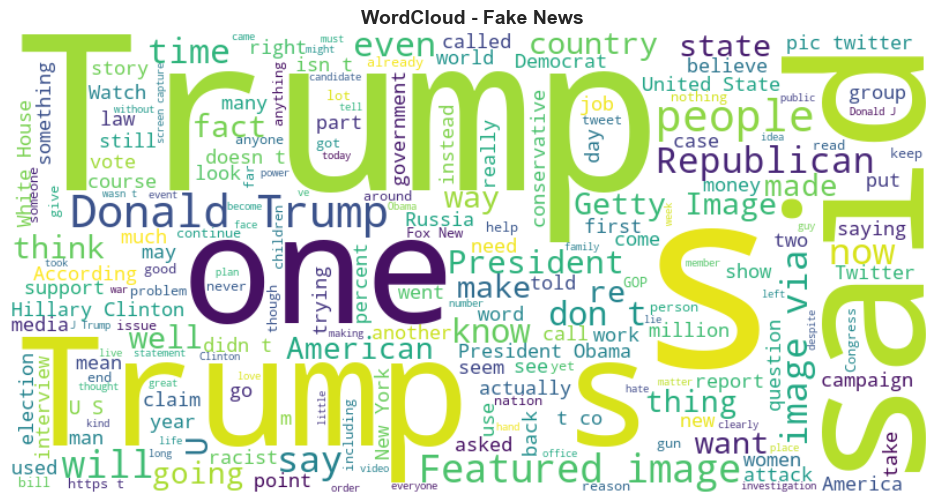

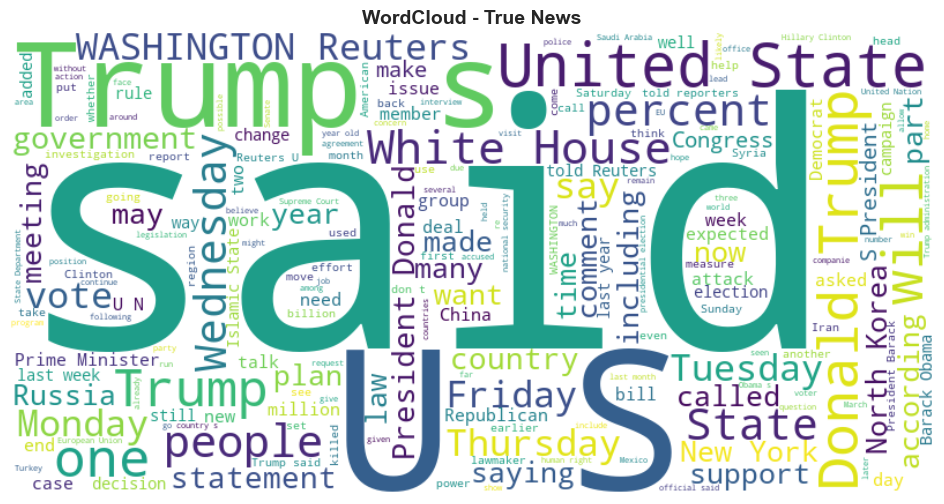

In [7]:
plot_wordclouds(df)

### Cell 8: Vẽ Top Features & Phân tích lỗi

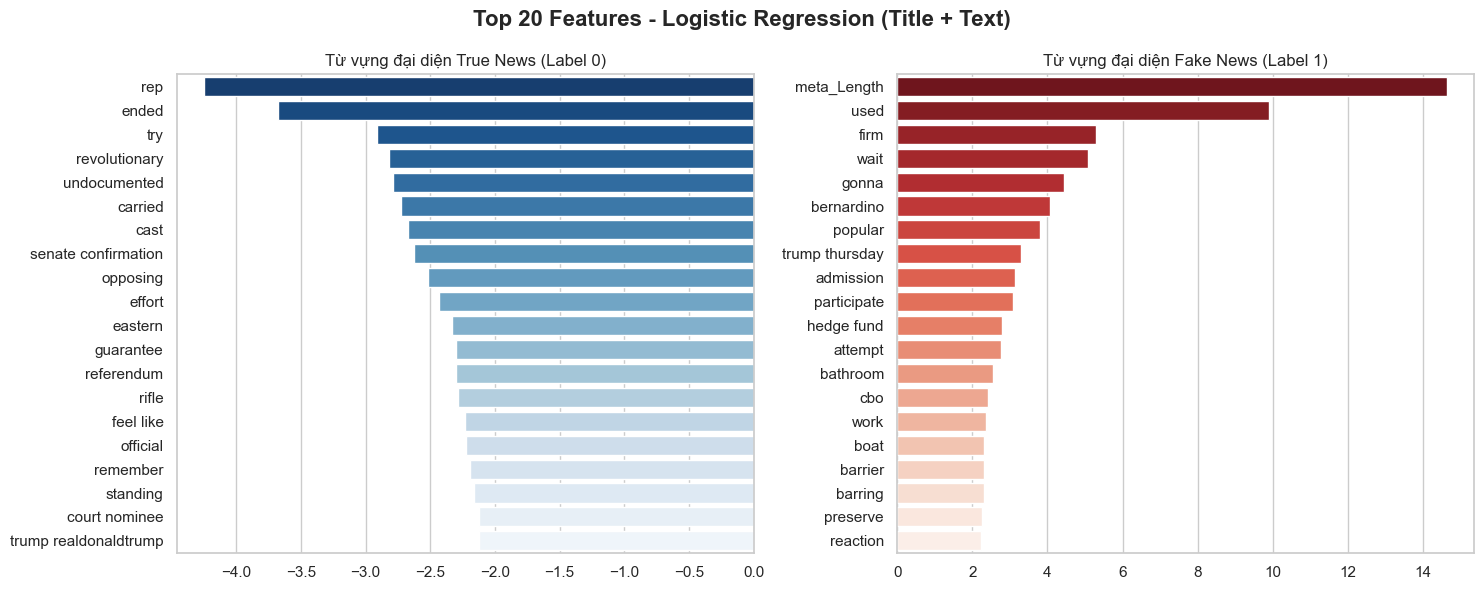

Tổng số sai: 2046 | False Positives: 122 | False Negatives: 1924

📌 TOP 10 FALSE POSITIVES:


,Title,Text,True Label,Predicted
27657,Russia says didn't promise withdrawal of pro-I...,MOSCOW (Reuters) - Russia has not promised to ...,0,1
27714,Ukraine prosecutor says puzzled by lack of U.S...,KIEV (Reuters) - Ukraine is puzzled by the lac...,0,1
27727,Ukraine's anti-corruption bureau launches case...,KIEV (Reuters) - Ukrainian investigators on Tu...,0,1
27739,Iraqi PM says 'will not wait forever' to take ...,BAGHDAD (Reuters) - Iraqi Prime Minister Haide...,0,1
27755,"Zimbabwe's army seizes power, Mugabe confined ...",HARARE (Reuters) - Zimbabwe s military seized ...,0,1
27785,EU concerned over challenges to Romanian judic...,BUCHAREST (Reuters) - Justice reform has stagn...,0,1
27814,Philippines' Duterte lauds China's help at 'cr...,MANILA (Reuters) - Philippine President Rodrig...,0,1
27816,Factbox: Key figures in Zimbabwe First Lady Gr...,HARARE (Reuters) - Following are key figures i...,0,1
27825,Russia's Lavrov says allegations of meddling i...,MOSCOW (Reuters) - Russian Foreign Minister Se...,0,1
27862,UK's Johnson vows no stone unturned to free ai...,LONDON (Reuters) - Foreign minister Boris John...,0,1



📌 TOP 10 FALSE NEGATIVES:


,Title,Text,True Label,Predicted
8566,ELLEN Just Proved She’s A HUGE Hypocrite And K...,Someone needs to educate Ellen DeGeneres on Pr...,1,0
8567,AFTER 5 YEARS Of Being Bullied By Barack Obama...,Freedom is not a gift from government. It is ...,1,0
8568,GOP VETERAN AND DOUBLE AMPUTEE Scorches Democr...,Brian Mast scorched the Democrats for their ly...,1,0
8569,HILARIOUS! Random French People Say They’d Gla...,Watch this hilarious video from our British co...,1,0
8570,ANGRY DAD CONFRONTS SCHOOL BOARD After Finding...,We can t say enough great things about this da...,1,0
8571,Mike Huckabee Posts ‘Super Racist’ Cinco De M...,"Ever since Donald Trump won the election, Repu...",1,0
8572,SENATOR FEINSTEIN Shocks CNN Anchor With “Prec...,"What s all the fuss about if there s no there,...",1,0
8573,NAIVE NEWS ANCHOR Reporting On “Refugees” Gets...,This is so disturbing but such a wake up call ...,1,0
8574,KELLYANNE CONWAY: “Where The Hell Were Those D...,Kellyanne Conway appeared on the Sean Hannity ...,1,0
8575,Seth Meyers Shows Clip After Clip Of Trump’s ...,Seth Meyers takes his A Closer Look segment ...,1,0


In [8]:
plot_top_features(tfidf_title, lr_model, "Logistic Regression (Title + Text)")

# Phân tích dự đoán sai cho mô hình tốt nhất
y_pred_best = lr_model.predict(X_test_title)
analyze_errors(df, test_idx, y_test, y_pred_best)